eps=0.2, min_samples=8
clusters found: 3
noise points:   35 / 640


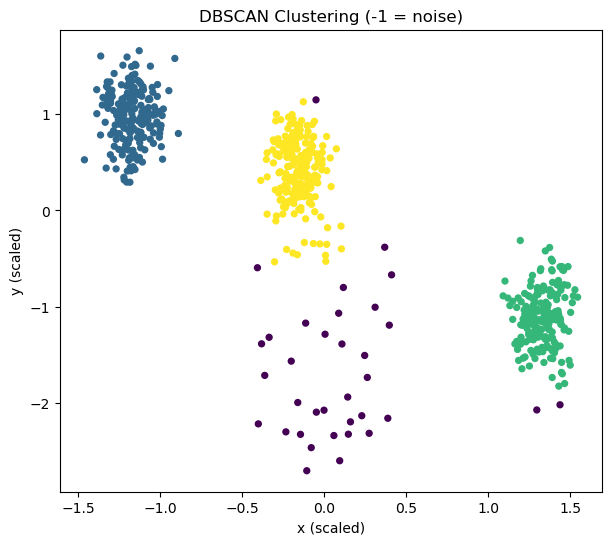

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons, make_blobs
from sklearn.preprocessing import StandardScaler

# ----------------------------
# 1) Make a dataset to cluster
# ----------------------------
# Option A: "two moons" (non-spherical clusters)
# X, _ = make_moons(n_samples=600, noise=0.08, random_state=7)

# Option B: blobs (more k-means-friendly)
X, _ = make_blobs(n_samples=600, centers=3, cluster_std=0.7, random_state=7)

# Add a few random outliers to show DBSCAN noise detection
rng = np.random.default_rng(7)
outliers = rng.uniform(low=-3, high=3, size=(40, 2))
X = np.vstack([X, outliers])

# Scale features (IMPORTANT for DBSCAN distance-based behavior)
X_scaled = StandardScaler().fit_transform(X)

# ----------------------------
# 2) Run DBSCAN
# ----------------------------
eps = 0.2     # try: 0.15, 0.2, 0.25, 0.3
min_samples = 8  # try: 4, 6, 8, 12

db = DBSCAN(eps=eps, min_samples=min_samples)
labels = db.fit_predict(X_scaled)

# ----------------------------
# 3) Inspect results
# ----------------------------
n_noise = np.sum(labels == -1)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f"eps={eps}, min_samples={min_samples}")
print(f"clusters found: {n_clusters}")
print(f"noise points:   {n_noise} / {len(labels)}")

# ----------------------------
# 4) Plot
# ----------------------------
plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, s=18)
plt.title("DBSCAN Clustering (-1 = noise)")
plt.xlabel("x (scaled)")
plt.ylabel("y (scaled)")
plt.show()


In [ ]:
# eps sweep: 0.15, 0.2, 0.25, 0.3
# min_samples sweep: 4, 6, 8, 12  
#how to do an eps sweep?  for each eps, try all min_samples values, and print results.
eps_values = [0.15, 0.2, 0.25, 0.3]
min_samples_values = [4, 6, 8, 12]
for eps in eps_values:
    for min_samples in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_scaled)
        n_noise = np.sum(labels == -1)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        print(f"eps={eps}, min_samples={min_samples}")
        print(f"clusters found: {n_clusters}")
        print(f"noise points:   {n_noise} / {len(labels)}")


eps=0.15, min_samples=4
clusters found: 5
noise points:   36 / 640
eps=0.15, min_samples=6
clusters found: 4
noise points:   42 / 640
eps=0.15, min_samples=8
clusters found: 3
noise points:   53 / 640
eps=0.15, min_samples=12
clusters found: 3
noise points:   58 / 640
eps=0.2, min_samples=4
clusters found: 5
noise points:   21 / 640
eps=0.2, min_samples=6
clusters found: 3
noise points:   33 / 640
eps=0.2, min_samples=8
clusters found: 3
noise points:   35 / 640
eps=0.2, min_samples=12
clusters found: 3
noise points:   49 / 640
eps=0.25, min_samples=4
clusters found: 5
noise points:   9 / 640
eps=0.25, min_samples=6
clusters found: 4
noise points:   18 / 640
eps=0.25, min_samples=8
clusters found: 4
noise points:   25 / 640
eps=0.25, min_samples=12
clusters found: 3
noise points:   35 / 640
eps=0.3, min_samples=4
clusters found: 4
noise points:   2 / 640
eps=0.3, min_samples=6
clusters found: 4
noise points:   12 / 640
eps=0.3, min_samples=8
clusters found: 4
noise points:   14 / 640
e

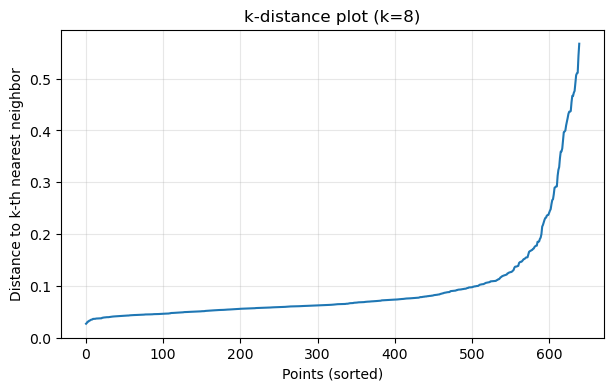

In [3]:
k = 8  # usually set to min_samples
nbrs = NearestNeighbors(n_neighbors=k).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)

k_dist = np.sort(distances[:, -1])  # distance to kth neighbor
plt.figure(figsize=(7, 4))
plt.plot(k_dist)
plt.title(f"k-distance plot (k={k})")
plt.xlabel("Points (sorted)")
plt.ylabel("Distance to k-th nearest neighbor")
plt.grid(True, alpha=0.3)
plt.show()

HBDscan practice


clusters found: 2
noise points:   36 / 640


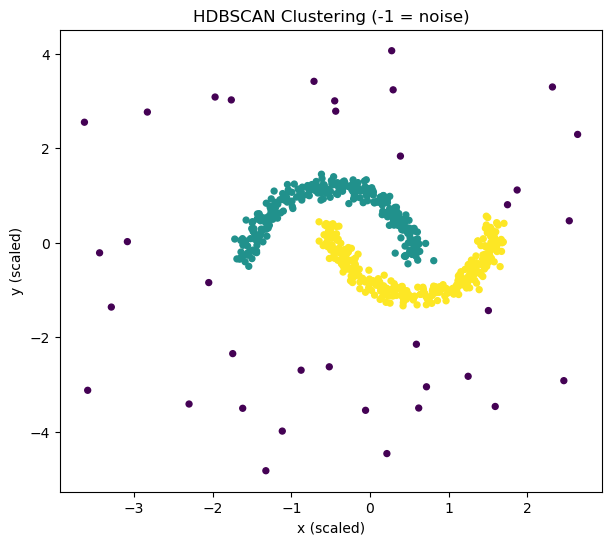

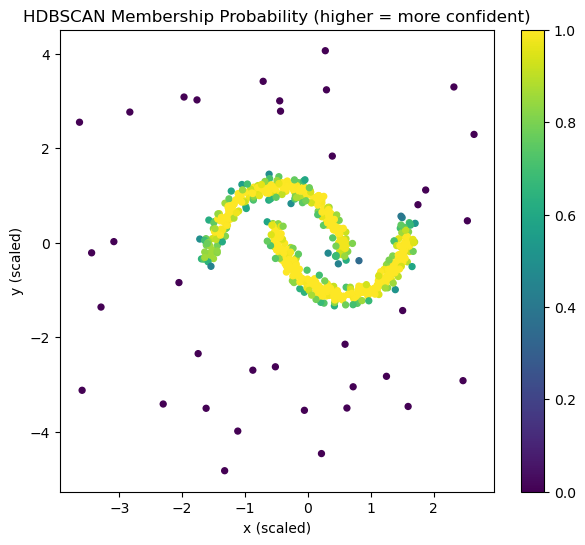

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import hdbscan 

from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
# 1) Data
X, _ = make_moons(n_samples=600, noise=0.08, random_state=7)

rng = np.random.default_rng(7)
outliers = rng.uniform(low=-3, high=3, size=(40, 2))
X = np.vstack([X, outliers])

X_scaled = StandardScaler().fit_transform(X)

# 2) HDBSCAN (install if needed)

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=20,   # try: 10, 20, 40
    min_samples=10,        # try: None, 5, 10, 20
    cluster_selection_method="eom"  # default; "leaf" gives finer clusters
)

labels = clusterer.fit_predict(X_scaled)

# 3) Quick stats
n_noise = np.sum(labels == -1)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f"clusters found: {n_clusters}")
print(f"noise points:   {n_noise} / {len(labels)}")

# 4) Plot labels
plt.figure(figsize=(7, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, s=18)
plt.title("HDBSCAN Clustering (-1 = noise)")
plt.xlabel("x (scaled)")
plt.ylabel("y (scaled)")
plt.show()

# 5) Plot membership strength (probabilities)
probs = clusterer.probabilities_
plt.figure(figsize=(7, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=probs, s=18)
plt.title("HDBSCAN Membership Probability (higher = more confident)")
plt.xlabel("x (scaled)")
plt.ylabel("y (scaled)")
plt.colorbar()
plt.show()
